In [1]:
import os
from pathlib import Path
import shutil
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

#настройка отображения
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
#компьютерное представление изображения
synthetic_array = np.array([
    [[255, 0, 0], [0, 255, 0], [0, 0, 255], [255, 255, 0]],
    [[255, 0, 255], [0, 255, 255], [128, 128, 128], [0, 0, 0]],
    [[255, 255, 255], [255, 165, 0], [128, 0, 128], [0, 128, 0]],
    [[255, 192, 203], [173, 216, 230], [255, 255, 0], [0, 255, 127]]
], dtype=np.uint8)

print("Тип данных массива:", synthetic_array.dtype)
print("Размерность:", synthetic_array.shape)
print("\nМатрица значений первого красного канала:\n", synthetic_array[:, :, 0])

#преобразуем массив обратно в объект Image
img_synthetic = Image.fromarray(synthetic_array)
img_synthetic.show()

Тип данных массива: uint8
Размерность: (4, 4, 3)

Матрица значений первого красного канала:
 [[255   0   0 255]
 [255   0 128   0]
 [255 255 128   0]
 [255 173 255   0]]


Тип (OpenCV): <class 'numpy.ndarray'>
Форма (H, W, C): (4, 4, 3)
dtype: uint8
Минимум / максимум по каналам: 0 255


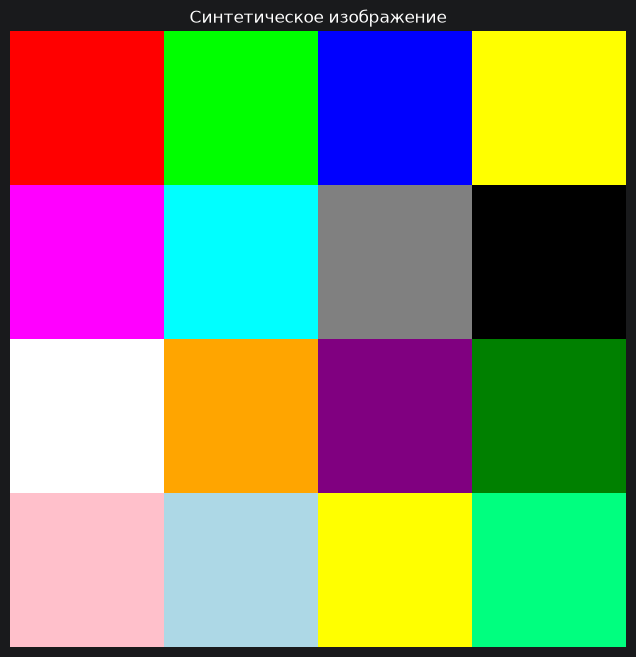

In [3]:
#изображение в OpenCV
synthetic_bgr = cv2.cvtColor(synthetic_array, cv2.COLOR_RGB2BGR)#преобразуем синтетический массив

print("Тип (OpenCV):", type(synthetic_bgr))
print("Форма (H, W, C):", synthetic_bgr.shape)
print("dtype:", synthetic_bgr.dtype)
print("Минимум / максимум по каналам:",
      synthetic_bgr.min(), synthetic_bgr.max())

plt.imshow(cv2.cvtColor(synthetic_bgr, cv2.COLOR_BGR2RGB))
plt.title("Синтетическое изображение")
plt.axis("off")
plt.show()

In [4]:
#сравнение synthetic_array и synthetic_bgr
print("synthetic_array (RGB):")
print(synthetic_array)
print("\nsynthetic_bgr (BGR):")
print(synthetic_bgr)

#принимаем np.ndarray и возвращаем информацию
def get_info(arr):
    info = {}
    info["форма"] = arr.shape
    info["тип"] = str(arr.dtype)
    info["минимум"] = int(arr.min())
    info["максимум"] = int(arr.max())

    #среднее по каждому каналу
    if arr.ndim == 3:
        means = []
        for i in range(arr.shape[2]):
            means.append(round(float(arr[:, :, i].mean()), 2))
        info["среднее по каналам"] = means
    else:
        info["среднее"] = round(float(arr.mean()), 2)
    return info

#проверка функции
print("\nИнформация о synthetic_array:")
print(get_info(synthetic_array))

print("\nИнформация о synthetic_bgr:")
print(get_info(synthetic_bgr))

synthetic_array (RGB):
[[[255   0   0]
  [  0 255   0]
  [  0   0 255]
  [255 255   0]]

 [[255   0 255]
  [  0 255 255]
  [128 128 128]
  [  0   0   0]]

 [[255 255 255]
  [255 165   0]
  [128   0 128]
  [  0 128   0]]

 [[255 192 203]
  [173 216 230]
  [255 255   0]
  [  0 255 127]]]

synthetic_bgr (BGR):
[[[  0   0 255]
  [  0 255   0]
  [255   0   0]
  [  0 255 255]]

 [[255   0 255]
  [255 255   0]
  [128 128 128]
  [  0   0   0]]

 [[255 255 255]
  [  0 165 255]
  [128   0 128]
  [  0 128   0]]

 [[203 192 255]
  [230 216 173]
  [  0 255 255]
  [127 255   0]]]

Информация о synthetic_array:
{'форма': (4, 4, 3), 'тип': 'uint8', 'минимум': 0, 'максимум': 255, 'среднее по каналам': [138.38, 147.44, 114.75]}

Информация о synthetic_bgr:
{'форма': (4, 4, 3), 'тип': 'uint8', 'минимум': 0, 'максимум': 255, 'среднее по каналам': [114.75, 147.44, 138.38]}


In [5]:
def load_and_inspect_image(filepath: str):
              #Pillow
    pil_img = Image.open(filepath)
    pil_np = np.array(pil_img)

    print(f"[PIL] Формат: {pil_img.format}")
    print(f"[PIL] Режим: {pil_img.mode}")
    print(f"[PIL] Размер: {pil_img.size}")
    print(f"[PIL] NumPy-форма: {pil_np.shape}")

               #OpenCV
    cv_img_bgr = cv2.imread(filepath)
    if cv_img_bgr is None:
        print("[OpenCV] Не удалось прочитать изображение.")
        return

    cv_img_rgb = cv2.cvtColor(cv_img_bgr, cv2.COLOR_BGR2RGB)
    print(f"[OpenCV] Форма BGR: {cv_img_bgr.shape}")
    print(f"[OpenCV] Минимум / максимум по каналам:",
          cv_img_bgr.min(), cv_img_bgr.max())
    img_gray = cv2.cvtColor(cv_img_bgr, cv2.COLOR_BGR2GRAY)
    img_small = cv2.resize(cv_img_bgr, (0, 0), fx=0.5, fy=0.5,
                           interpolation=cv2.INTER_AREA)

     #визуальное сравнение
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].set_title('Pillow (RGB)')
    axes[0].imshow(pil_np)
    axes[0].axis('off')

    axes[1].set_title('OpenCV (BGR->RGB)')
    axes[1].imshow(cv_img_rgb)
    axes[1].axis('off')

    axes[2].set_title('Серое (OpenCV)')
    axes[2].imshow(img_gray, cmap='gray')
    axes[2].axis('off')

    axes[3].set_title('Уменьшенное (OpenCV)')
    axes[3].imshow(cv2.cvtColor(img_small, cv2.COLOR_BGR2RGB))
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

    #Гистограмма яркостей для img_gray
    hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])

    plt.figure(figsize=(8, 4))
    plt.plot(hist)
    plt.title("Гистограмма яркостей (img_gray)")
    plt.xlabel("Яркость")
    plt.ylabel("Количество пикселей")
    plt.xlim([0, 256])
    plt.show()

#пример
sample_path = "./butterfly.jpg"
if os.path.exists(sample_path):
    load_and_inspect_image(sample_path)

In [6]:
def visualize_color_spaces(image_path: str):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print("Не удалось загрузить изображение:", image_path)
        return

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)

    #инверсия
    inverted = 255 - img_rgb
    r_channel, g_channel, b_channel = cv2.split(img_rgb)

    titles = ['Оригинал (RGB)', 'GRAY', 'HSV', 'LAB','YCrCb', 'Инверсия', 'Красный канал', 'Зелёный канал', 'Синий канал']
    images_to_show = [img_rgb, gray, hsv, lab, ycrcb, inverted, r_channel, g_channel, b_channel]

    fig, axes = plt.subplots(3, 3, figsize=(16, 14))
    axes = axes.ravel()

    for ax, img, title in zip(axes, images_to_show, titles):
        if img.ndim == 2:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(img)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()